In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [5]:
# Experimenting with importing shapefiles and emissions
shapes = '/glade/campaign/acom/MUSICA/emis/htap3/regional_mask_0.1deg.nc'
ds_mask = xr.open_dataset(shapes)

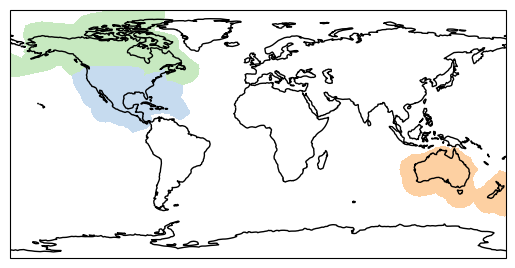

In [3]:
# Extract the Australian and North American regions
lat = ds_mask.latitude
lon = ds_mask.longitude
reg = ds_mask.region_mask
BNA = reg.sel(region = 'BNA') # Boreal North America
TNA = reg.sel(region = 'TNA') # Temperate North America
ANZ = reg.sel(region = 'ANZ') # Australia and New Zealand

# Map each region using matplotlib
BNA_only = BNA.where(BNA.values == 1) # Ensures the dataset is made entirely of the regional values
TNA_only = TNA.where(TNA.values == 1)
ANZ_only = ANZ.where(ANZ.values == 1)

# Setting up figure settings
proj = ccrs.PlateCarree()
fig = plt.figure()
ax = plt.axes(projection = proj)
ax.coastlines()

# Mapping each shape on the global map
clrs = [matplotlib.cm.Greens, matplotlib.cm.Blues, matplotlib.cm.Oranges]
n=0
for region in [BNA_only, TNA_only, ANZ_only]:
    h = ax.contourf(lon, lat, region, transform=ccrs.PlateCarree(), cmap=clrs[n])
    n+=1